In [5]:
# ============================================================
# CELL 1: Setup & Imports
# ============================================================
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
import os
import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("..", "src")))
from data_loader import DataLoader

np.random.seed(42)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")
plt.rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 14})

FIGURES_DIR = os.path.abspath(os.path.join("..", "figures"))
os.makedirs(FIGURES_DIR, exist_ok=True)
print("✅ Setup complete.")

✅ Setup complete.


In [6]:
# ============================================================
# CELL 2: Load Data (Section 1 — Data Preparation)
# ============================================================
loader = DataLoader()

promotions = loader.load("promotions")
order_items = loader.load("order_items")
orders = loader.load("orders")

print(f"promotions:  {promotions.shape}")
print(f"order_items: {order_items.shape}")
print(f"orders:      {orders.shape}")

promotions:  (50, 10)
order_items: (714669, 7)
orders:      (646945, 8)


In [7]:
# ============================================================
# CELL 3: Quick Schema Inspection
# ============================================================
print("=== promotions columns ===")
print(promotions.schema)
print(promotions.head(3))

print("\n=== order_items columns ===")
print(order_items.schema)
print(order_items.head(3))

print("\n=== orders columns ===")
print(orders.schema)
print(orders.head(3))

=== promotions columns ===
Schema([('promo_id', String), ('promo_name', String), ('promo_type', String), ('discount_value', Float64), ('start_date', String), ('end_date', String), ('applicable_category', String), ('promo_channel', String), ('stackable_flag', Int64), ('min_order_value', Int64)])
shape: (3, 10)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ promo_id  ┆ promo_nam ┆ promo_typ ┆ discount_ ┆ … ┆ applicabl ┆ promo_cha ┆ stackable ┆ min_orde │
│ ---       ┆ e         ┆ e         ┆ value     ┆   ┆ e_categor ┆ nnel      ┆ _flag     ┆ r_value  │
│ str       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ y         ┆ ---       ┆ ---       ┆ ---      │
│           ┆ str       ┆ str       ┆ f64       ┆   ┆ ---       ┆ str       ┆ i64       ┆ i64      │
│           ┆           ┆           ┆           ┆   ┆ str       ┆           ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪══════

In [8]:
# ============================================================
# CELL 4: Merge into Master DataFrame
# ============================================================
# Step 1: order_items + orders on order_id
master = order_items.join(orders, on="order_id", how="left")

# Step 2: left join with promotions on promo_id
master = master.join(promotions, on="promo_id", how="left")

# Tạo cột line_revenue = quantity * unit_price - discount_amount
master = master.with_columns(
    (pl.col("quantity") * pl.col("unit_price") - pl.col("discount_amount")).alias(
        "line_revenue"
    )
)

print(f"Master DataFrame shape: {master.shape}")
print(master.head(5))


Master DataFrame shape: (714669, 24)
shape: (5, 24)
┌──────────┬────────────┬──────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ order_id ┆ product_id ┆ quantity ┆ unit_pric ┆ … ┆ promo_cha ┆ stackable ┆ min_order ┆ line_reve │
│ ---      ┆ ---        ┆ ---      ┆ e         ┆   ┆ nnel      ┆ _flag     ┆ _value    ┆ nue       │
│ i64      ┆ i64        ┆ i64      ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│          ┆            ┆          ┆ f64       ┆   ┆ str       ┆ i64       ┆ i64       ┆ f64       │
╞══════════╪════════════╪══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 1        ┆ 2400       ┆ 7        ┆ 1138.22   ┆ … ┆ null      ┆ null      ┆ null      ┆ 7967.54   │
│ 2        ┆ 609        ┆ 7        ┆ 10166.25  ┆ … ┆ null      ┆ null      ┆ null      ┆ 71163.75  │
│ 3        ┆ 396        ┆ 3        ┆ 11220.33  ┆ … ┆ null      ┆ null      ┆ null      ┆ 33660.99  │
│ 4        ┆ 635        ┆ 5        ┆ 10

# ============================================================
# SECTION 2: DATA QUALITY ASSURANCE (DQA)
# ============================================================

In [9]:
# ============================================================
# SECTION 2: DATA QUALITY ASSURANCE (DQA)
# ============================================================

# ============================================================
# CELL 5: 2.1 — Missing / Null Values Analysis
# ============================================================
null_counts = master.null_count()
total_rows = master.height

print("=== Null Count per Column ===")
for col_name in master.columns:
    n_null = null_counts[col_name][0]
    pct = n_null / total_rows * 100
    if n_null > 0:
        print(f"  {col_name:25s} -> {n_null:>10,} nulls  ({pct:.2f}%)")

=== Null Count per Column ===
  promo_id                  ->    438,353 nulls  (61.34%)
  promo_id_2                ->    714,463 nulls  (99.97%)
  promo_name                ->    438,353 nulls  (61.34%)
  promo_type                ->    438,353 nulls  (61.34%)
  discount_value            ->    438,353 nulls  (61.34%)
  start_date                ->    438,353 nulls  (61.34%)
  end_date                  ->    438,353 nulls  (61.34%)
  applicable_category       ->    684,814 nulls  (95.82%)
  promo_channel             ->    438,353 nulls  (61.34%)
  stackable_flag            ->    438,353 nulls  (61.34%)
  min_order_value           ->    438,353 nulls  (61.34%)


In [31]:
# ============================================================
# CELL 6: 2.1b — Fill Null for promo columns
# ============================================================
# promo_id null => đơn hàng không sử dụng khuyến mãi
promo_str_cols = ["promo_id", "promo_name", "promo_type", "promo_channel"]
for c in promo_str_cols:
    if c in master.columns:
        master = master.with_columns(pl.col(c).fill_null("No_Promo"))

# Fill numeric promo cols with 0
promo_num_cols = ["discount_value", "min_order_value", "stackable_flag"]
for c in promo_num_cols:
    if c in master.columns:
        master = master.with_columns(pl.col(c).fill_null(0))

# 3. Drop cột quá nhiều Null
master = master.drop(["promo_id_2", "applicable_category"])


print("✅ Null values filled for promo columns.")
print(f"Remaining total nulls: {master.null_count().sum_horizontal()[0]}")

✅ Null values filled for promo columns.
Remaining total nulls: 876706


In [32]:
# ============================================================
# CELL 7: 2.2 — Validate Data Types
# ============================================================
# Cast ID columns to String
id_cols = ["order_id", "product_id", "customer_id", "promo_id"]
for c in id_cols:
    if c in master.columns:
        master = master.with_columns(pl.col(c).cast(pl.Utf8))

# Cast numeric columns to Float64
num_cols = ["unit_price", "discount_amount", "line_revenue", "discount_value"]
for c in num_cols:
    if c in master.columns:
        master = master.with_columns(pl.col(c).cast(pl.Float64))

print("✅ Data types validated.")
print(master.schema)

✅ Data types validated.
Schema([('order_id', String), ('product_id', String), ('quantity', Int64), ('unit_price', Float64), ('discount_amount', Float64), ('promo_id', String), ('order_date', Date), ('customer_id', String), ('zip', Int64), ('order_status', String), ('payment_method', String), ('device_type', String), ('order_source', String), ('promo_name', String), ('promo_type', String), ('discount_value', Float64), ('start_date', String), ('end_date', String), ('promo_channel', String), ('stackable_flag', Int64), ('min_order_value', Int64), ('line_revenue', Float64), ('flag_negative_revenue', Boolean), ('has_promo_label', String), ('year', Int32), ('month', Int8), ('quarter', Int8), ('promo_stack_label', String), ('has_promotion', Int32), ('discount_pct', Float64)])


In [33]:
# ============================================================
# CELL 8: 2.3 — Outlier Detection (IQR method)
# ============================================================
def detect_outliers_iqr(df: pl.DataFrame, col: str) -> dict:
    """Detect outliers using IQR method. Returns stats dict."""
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = df.filter(
        (pl.col(col) < lower) | (pl.col(col) > upper)
    ).height
    return {
        "column": col,
        "Q1": q1, "Q3": q3, "IQR": iqr,
        "lower_bound": lower, "upper_bound": upper,
        "n_outliers": n_outliers,
        "pct_outliers": n_outliers / df.height * 100,
    }


outlier_cols = ["unit_price", "discount_amount", "line_revenue", "quantity"]
outlier_results = []
for c in outlier_cols:
    if c in master.columns:
        stats = detect_outliers_iqr(master, c)
        outlier_results.append(stats)
        print(f"[{c}] Outliers: {stats['n_outliers']:,} ({stats['pct_outliers']:.2f}%) "
              f"| Bounds: [{stats['lower_bound']:.2f}, {stats['upper_bound']:.2f}]")

[unit_price] Outliers: 8,623 (1.21%) | Bounds: [-6143.41, 15324.07]
[discount_amount] Outliers: 105,767 (14.80%) | Bounds: [-1451.44, 2419.07]
[line_revenue] Outliers: 36,146 (5.06%) | Bounds: [-30849.15, 67526.29]
[quantity] Outliers: 0 (0.00%) | Bounds: [-4.00, 12.00]


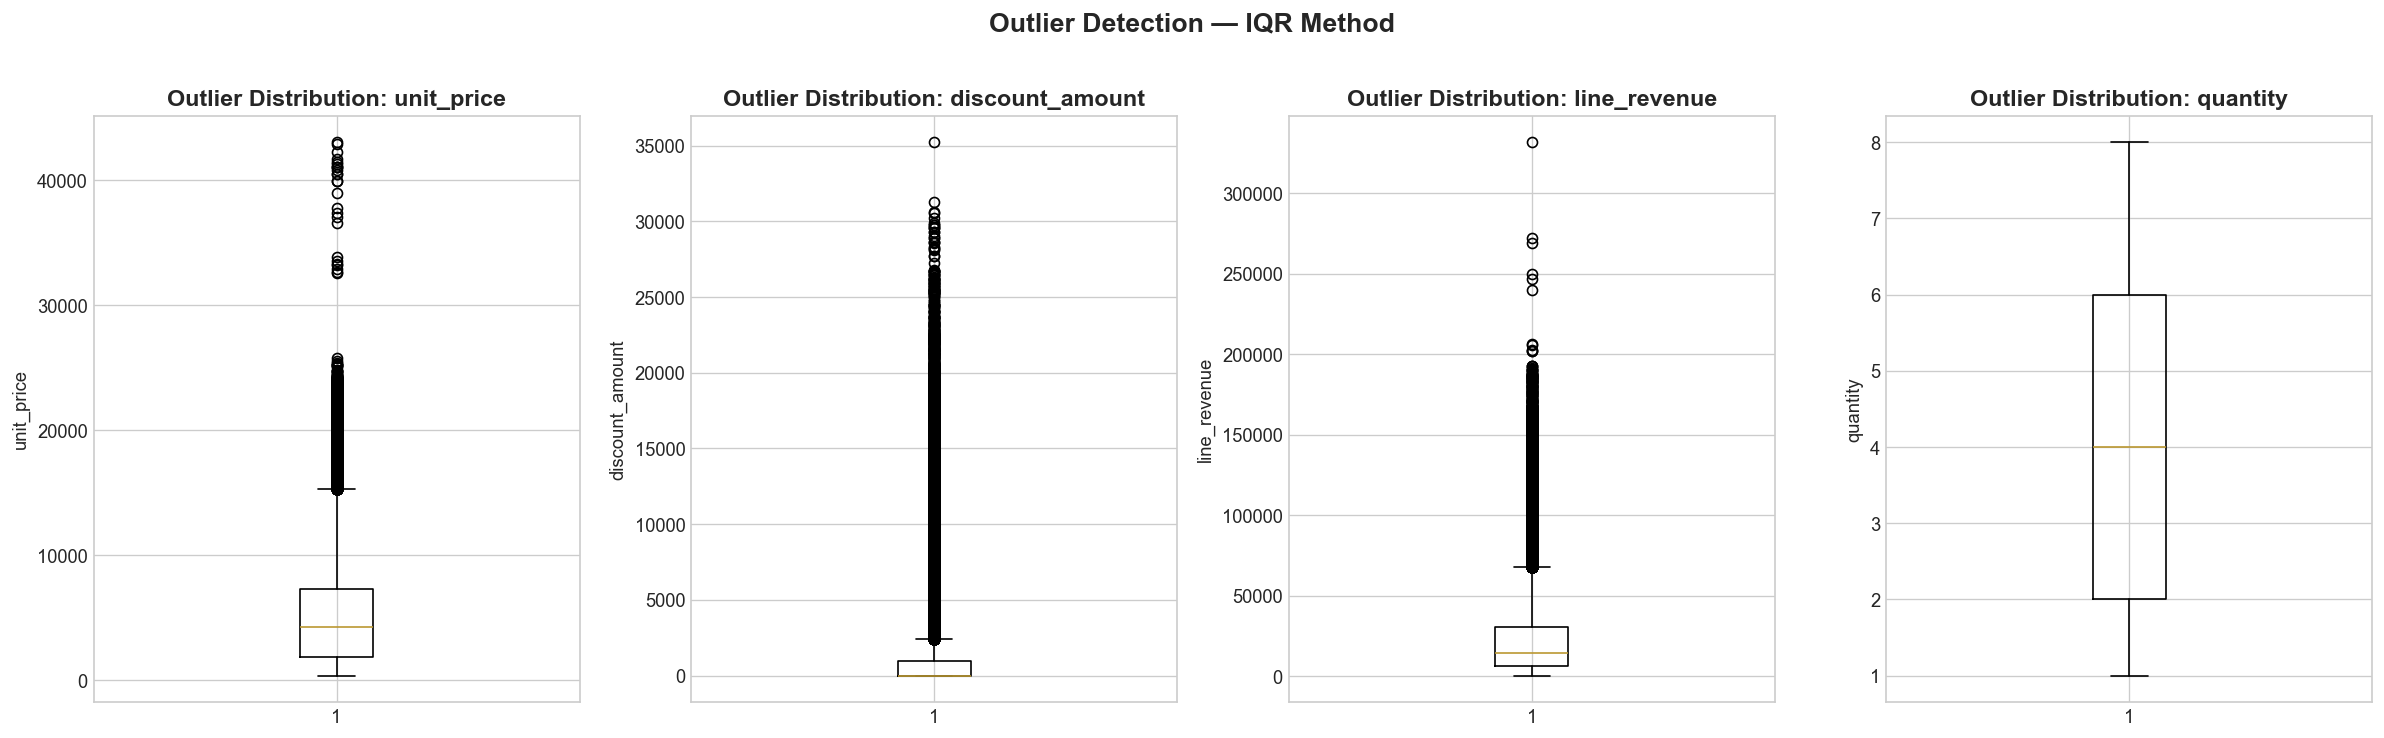

In [34]:
# ============================================================
# CELL 9: 2.3b — Visualize Outliers (Boxplots)
# ============================================================
fig, axes = plt.subplots(1, len(outlier_cols), figsize=(5 * len(outlier_cols), 6))
if len(outlier_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, outlier_cols):
    if col in master.columns:
        data = master[col].drop_nulls().to_list()
        ax.boxplot(data, vert=True)
        ax.set_title(f"Outlier Distribution: {col}", fontweight="bold")
        ax.set_ylabel(col)

plt.suptitle("Outlier Detection — IQR Method", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "day3_outlier_boxplots.png"), bbox_inches="tight")
plt.show()

In [35]:

# ============================================================
# CELL 10: 2.3c — Sanity Checks (logic-based)
# ============================================================
# Check: discount_amount > line_revenue (vô lý)
neg_revenue = master.filter(pl.col("line_revenue") < 0)
print(f"⚠️  Đơn hàng có line_revenue < 0: {neg_revenue.height:,}")

# Check: discount_amount lớn hơn giá trị đơn
if "discount_amount" in master.columns:
    illogical = master.filter(
        pl.col("discount_amount") > (pl.col("quantity") * pl.col("unit_price"))
    )
    print(f"⚠️  discount_amount > order value: {illogical.height:,}")

# Decision: Giữ nguyên dữ liệu nhưng flag lại
master = master.with_columns(
    (pl.col("line_revenue") < 0).alias("flag_negative_revenue")
)
print("✅ Flagged anomalies. Keeping data for now (không drop, chỉ flag).")

⚠️  Đơn hàng có line_revenue < 0: 0
⚠️  discount_amount > order value: 0
✅ Flagged anomalies. Keeping data for now (không drop, chỉ flag).


# ============================================================
# SECTION 3: EXPLORATORY DATA ANALYSIS
# ============================================================

shape: (2, 3)
┌─────────────────┬──────────┬───────────┐
│ has_promo_label ┆ n_orders ┆ pct       │
│ ---             ┆ ---      ┆ ---       │
│ str             ┆ u32      ┆ f64       │
╞═════════════════╪══════════╪═══════════╡
│ No Promotion    ┆ 438353   ┆ 61.336507 │
│ Has Promotion   ┆ 276316   ┆ 38.663493 │
└─────────────────┴──────────┴───────────┘


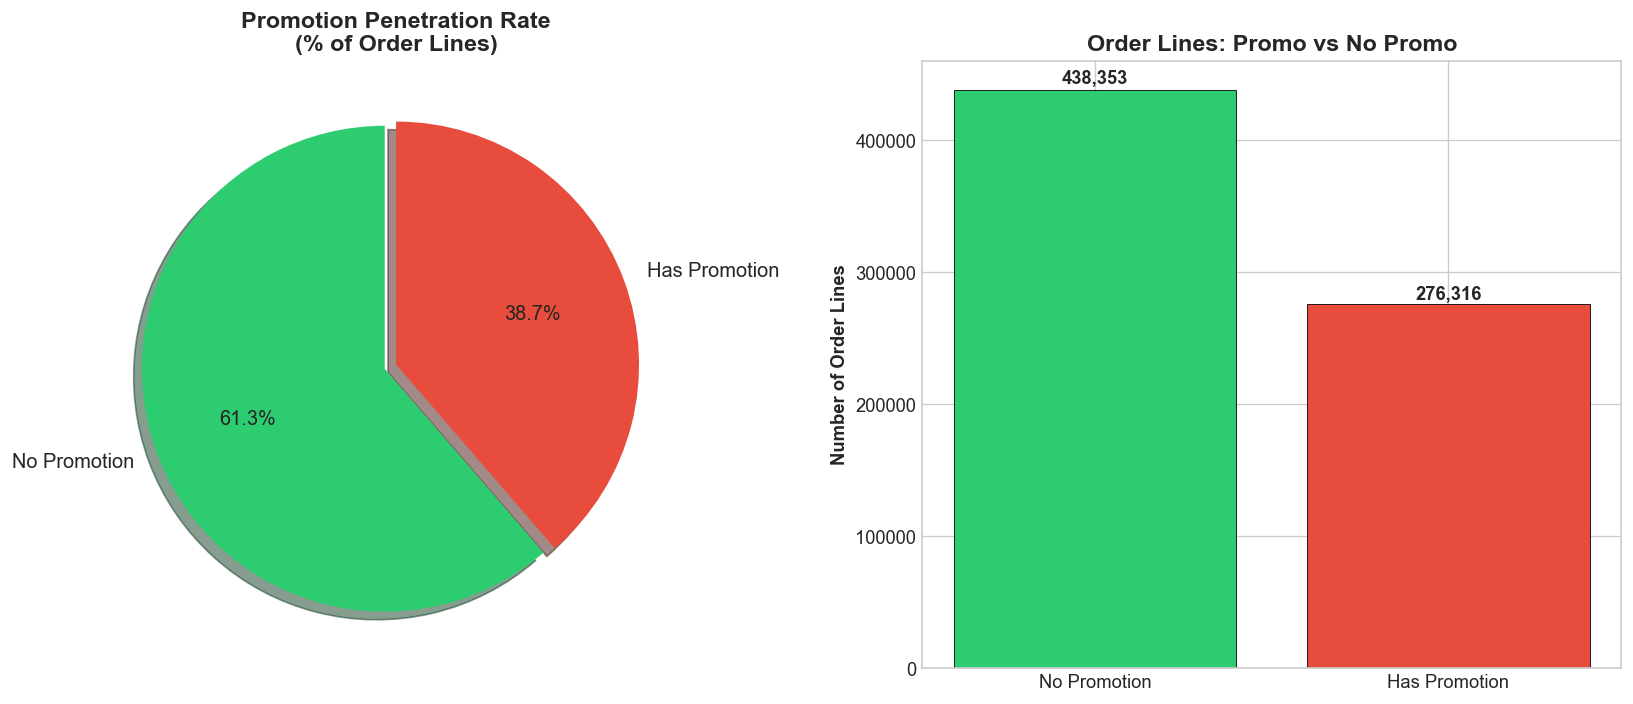

In [37]:
# ============================================================
# CELL 11: 3.1 — Promotion Penetration Rate
# ============================================================
master = master.with_columns(
    pl.when(pl.col("promo_type") == "No_Promo")
    .then(pl.lit("No Promotion"))
    .otherwise(pl.lit("Has Promotion"))
    .alias("has_promo_label")
)

promo_counts = master.group_by("has_promo_label").agg(
    pl.count().alias("n_orders"),
)
promo_counts = promo_counts.with_columns(
    (pl.col("n_orders") / pl.col("n_orders").sum() * 100).alias("pct")
)
print(promo_counts)

# Pie chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

labels = promo_counts["has_promo_label"].to_list()
sizes = promo_counts["n_orders"].to_list()
colors = ["#2ecc71", "#e74c3c"]
explode = (0.05, 0)

axes[0].pie(sizes, explode=explode, labels=labels, colors=colors,
            autopct="%1.1f%%", shadow=True, startangle=90,
            textprops={"fontsize": 12})
axes[0].set_title("Promotion Penetration Rate\n(% of Order Lines)", fontweight="bold")

# Bar chart
axes[1].bar(labels, sizes, color=colors, edgecolor="black", linewidth=0.5)
for i, (lbl, val) in enumerate(zip(labels, sizes)):
    axes[1].text(i, val + val * 0.01, f"{val:,}", ha="center", fontweight="bold")
axes[1].set_ylabel("Number of Order Lines", fontweight="bold")
axes[1].set_title("Order Lines: Promo vs No Promo", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "day3_promo_penetration.png"), bbox_inches="tight")
plt.show()

## 💡 Business Insights: Promotion Penetration Rate

**1. Tỷ lệ áp dụng khuyến mãi ở mức trung bình - thấp (38.7%):** 
Chỉ có khoảng gần 4 trên 10 sản phẩm (order lines) được bán ra dưới sự tác động của các chương trình khuyến mãi. Điều này cho thấy chiến lược giảm giá của doanh nghiệp đang được kiểm soát khá chặt chẽ, không lạm dụng việc "xả hàng" tràn lan.

**2. Động lực doanh thu đến từ nhu cầu tự nhiên (Organic Demand):**
Hơn 61.3% lượng sản phẩm tiêu thụ là hàng nguyên giá (No Promotion). Đây là một tín hiệu rất tích cực về sức khỏe thương hiệu (Brand Health) và độ trung thành của khách hàng, giúp doanh nghiệp duy trì được biên lợi nhuận (Profit Margin) ổn định mà không cần phụ thuộc quá nhiều vào việc cắt giảm giá.

**3. Tiềm năng tối ưu hóa (Actionable Takeaway):**
Vì tỷ lệ thâm nhập mới đạt 38.7%, đội ngũ Marketing vẫn còn không gian (room) để tung ra các chiến dịch nhắm mục tiêu (Targeted Campaigns) nhằm kích cầu ở những tập khách hàng chưa từng dùng khuyến mãi, hoặc đẩy mạnh bán chéo (Cross-sell) để gia tăng khối lượng đơn hàng.

**📌 Đối với mô hình Forecasting:**
Biến `has_promotion` sẽ đóng vai trò rất quan trọng để mô hình học được đâu là "Baseline Sales" (doanh thu nền tảng ổn định từ 61.3% đơn hàng tự nhiên) và đâu là "Sales Spikes" (các đỉnh doanh thu do 38.7% đơn khuyến mãi tạo ra).


In [49]:
# ============================================================
# CELL 12: 3.2 — Revenue & AOV Comparison
# ============================================================
# Aggregate tổng revenue và AOV theo nhóm promo
revenue_comparison = master.group_by("has_promo_label").agg(
    pl.col("line_revenue").sum().alias("total_revenue"),
    pl.col("line_revenue").mean().alias("avg_order_value"),
    pl.col("line_revenue").median().alias("median_order_value"),
    pl.col("line_revenue").std().alias("std_order_value"),
    pl.count().alias("n_orders"),
)
print("=== Revenue & AOV by Promo Group ===")
print(revenue_comparison)

=== Revenue & AOV by Promo Group ===
shape: (2, 6)
┌─────────────────┬───────────────┬─────────────────┬─────────────────┬─────────────────┬──────────┐
│ has_promo_label ┆ total_revenue ┆ avg_order_value ┆ median_order_va ┆ std_order_value ┆ n_orders │
│ ---             ┆ ---           ┆ ---             ┆ lue             ┆ ---             ┆ ---      │
│ str             ┆ f64           ┆ f64             ┆ ---             ┆ f64             ┆ u32      │
│                 ┆               ┆                 ┆ f64             ┆                 ┆          │
╞═════════════════╪═══════════════╪═════════════════╪═════════════════╪═════════════════╪══════════╡
│ No Promotion    ┆ 1.0995e10     ┆ 25082.613905    ┆ 17304.51        ┆ 23747.677467    ┆ 438353   │
│ Has Promotion   ┆ 4.6858e9      ┆ 16958.229753    ┆ 11081.94        ┆ 16856.703793    ┆ 276316   │
└─────────────────┴───────────────┴─────────────────┴─────────────────┴─────────────────┴──────────┘


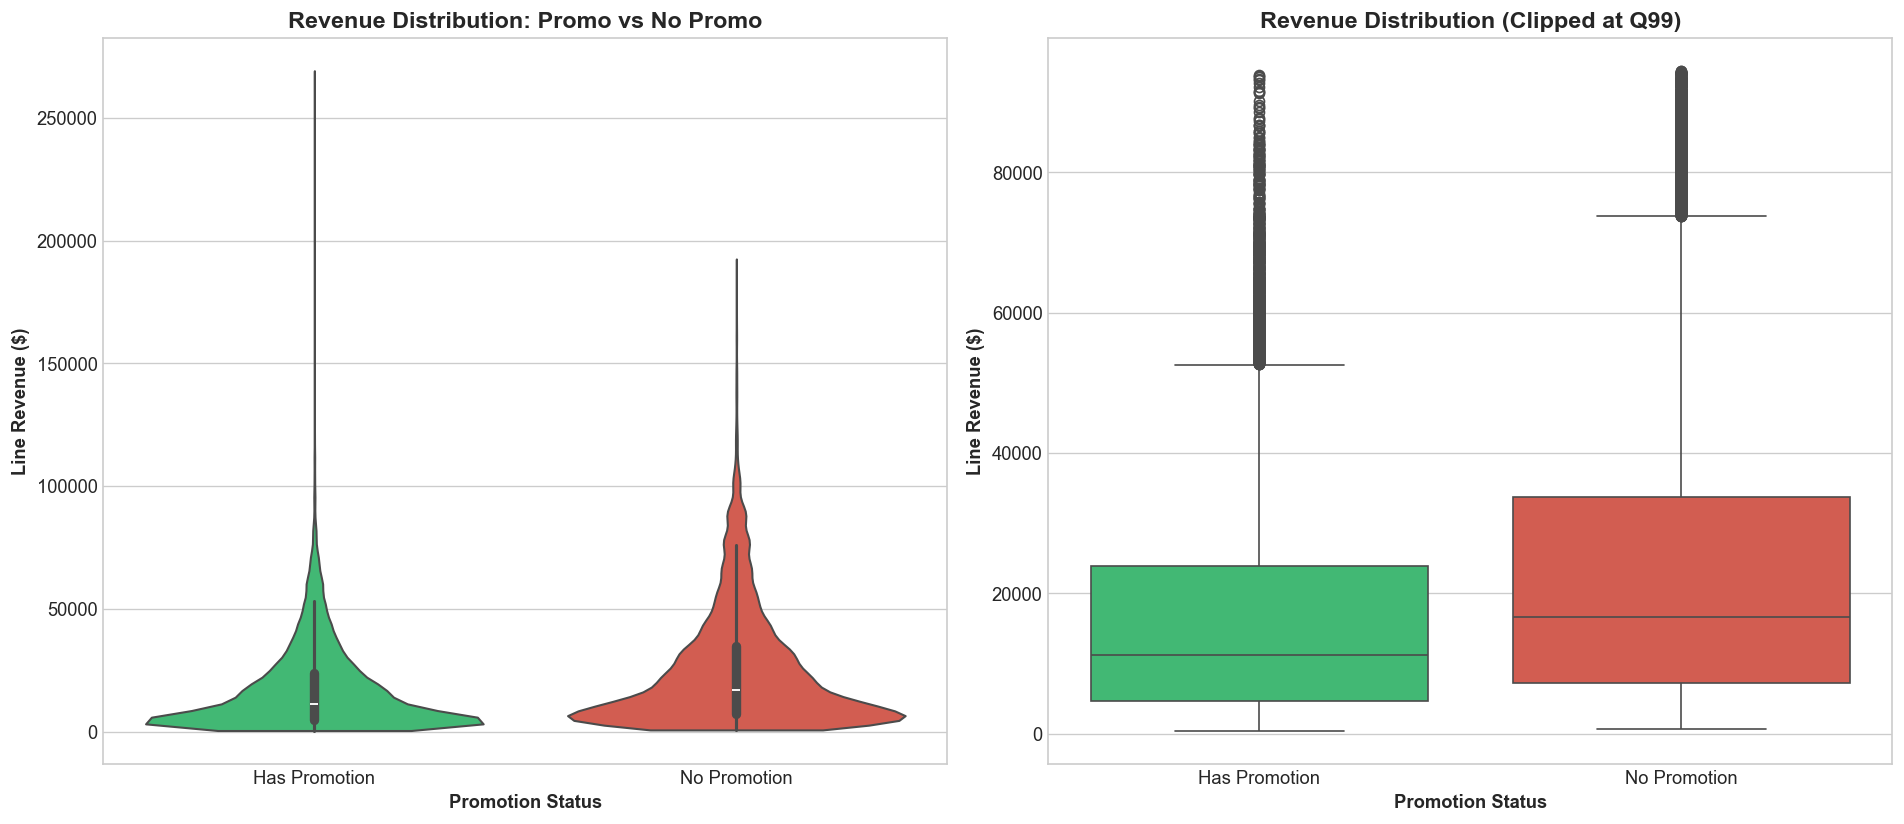

In [50]:

# ============================================================
# CELL 13: 3.2b — Violin Plot: Revenue Distribution
# ============================================================
# Sample để vẽ nhanh nếu data quá lớn
sample_size = min(50_000, master.height)
sample_df = master.sample(n=sample_size, seed=42).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Violin plot
sns.violinplot(data=sample_df, x="has_promo_label", y="line_revenue",
               palette=["#2ecc71", "#e74c3c"], ax=axes[0], cut=0)
axes[0].set_title("Revenue Distribution: Promo vs No Promo", fontweight="bold")
axes[0].set_xlabel("Promotion Status", fontweight="bold")
axes[0].set_ylabel("Line Revenue ($)", fontweight="bold")

# Boxplot (zoomed — clip to Q99 for readability)
q99 = sample_df["line_revenue"].quantile(0.99)
clipped = sample_df[sample_df["line_revenue"] <= q99]
sns.boxplot(data=clipped, x="has_promo_label", y="line_revenue",
            palette=["#2ecc71", "#e74c3c"], ax=axes[1])
axes[1].set_title("Revenue Distribution (Clipped at Q99)", fontweight="bold")
axes[1].set_xlabel("Promotion Status", fontweight="bold")
axes[1].set_ylabel("Line Revenue ($)", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "day3_revenue_violin_box.png"), bbox_inches="tight")
plt.show()


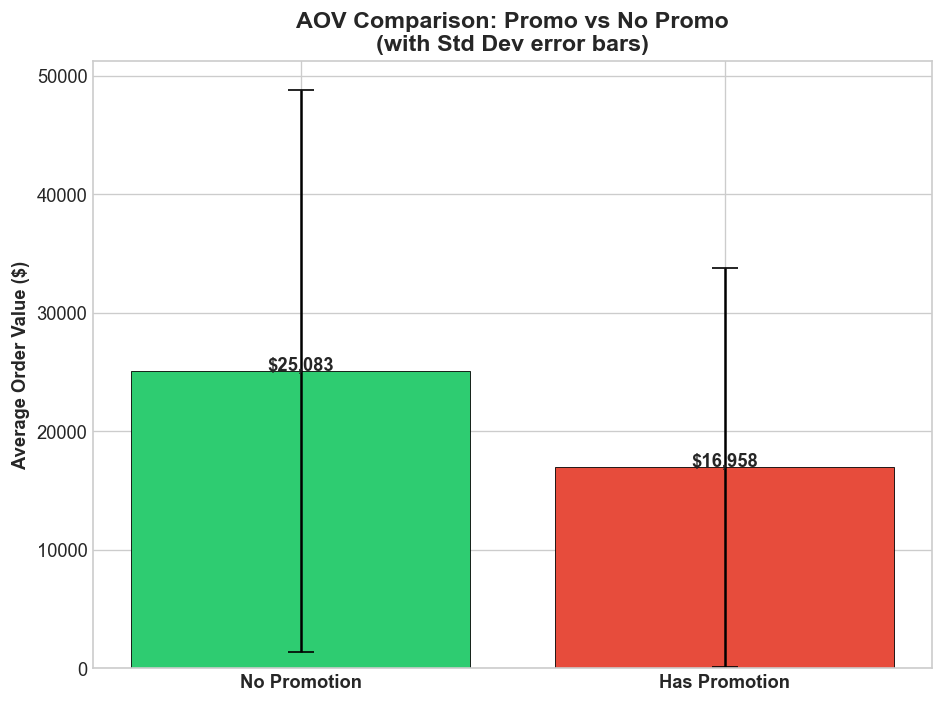

In [51]:
# ============================================================
# CELL 14: 3.2c — AOV Bar Chart with Error Bars
# ============================================================
rev_pd = revenue_comparison.to_pandas()

fig, ax = plt.subplots(figsize=(8, 6))
x_pos = range(len(rev_pd))
bars = ax.bar(x_pos, rev_pd["avg_order_value"],
              yerr=rev_pd["std_order_value"],
              color=["#2ecc71", "#e74c3c"], edgecolor="black",
              capsize=8, linewidth=0.5)
ax.set_xticks(x_pos)
ax.set_xticklabels(rev_pd["has_promo_label"], fontweight="bold")
ax.set_ylabel("Average Order Value ($)", fontweight="bold")
ax.set_title("AOV Comparison: Promo vs No Promo\n(with Std Dev error bars)", fontweight="bold")

for bar, val in zip(bars, rev_pd["avg_order_value"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"${val:,.0f}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "day3_aov_comparison.png"), bbox_inches="tight")
plt.show()

### 💡 Business Insights: Revenue & AOV Comparison

**1. Khuyến mãi đang kéo Giá trị đơn hàng trung bình (AOV) đi xuống:**
Trái với kỳ vọng thông thường rằng khuyến mãi sẽ kích thích khách hàng mua nhiều hơn để hóa đơn to hơn, dữ liệu cho thấy điều ngược lại. Nhóm đơn hàng **Có khuyến mãi** có AOV chỉ đạt **$16,958**, thấp hơn đến **32.4%** so với nhóm **Không có khuyến mãi ($25,083)**. 

**2. Sự khác biệt về phân phối giá trị (Distribution & Variance):**
Nhìn vào biểu đồ Boxplot và chỉ số Median, ta thấy giá trị trung vị của nhóm không khuyến mãi ($17,304) cao hơn hẳn nhóm có khuyến mãi ($11,081). Độ lệch chuẩn (Standard Deviation) của nhóm Không khuyến mãi ($23,747) cũng lớn hơn nhiều. Điều này chứng tỏ:
*   Các đơn hàng giá trị cực cao (Premium items hoặc đơn sỉ B2B) thường được chốt mua bất chấp việc có mã giảm giá hay không (cầu ít co giãn theo giá).
*   Các chiến dịch khuyến mãi hiện tại dường như chỉ đang thu hút tệp khách hàng mua các sản phẩm rẻ tiền, hoặc mức chiết khấu đang quá sâu khiến doanh thu thực thu (Net Revenue) trên mỗi dòng sản phẩm bị kéo tụt một cách nghiêm trọng.

**3. Đề xuất hành động (Actionable Takeaway):**
Doanh nghiệp cần xem xét lại cơ chế (mechanics) của các chương trình Promotion. Thay vì giảm giá trực tiếp cho các món hàng rẻ, nên thiết kế các chương trình khuyến mãi dạng "Tiered" (Mua càng nhiều giảm càng nhiều) hoặc áp dụng mức chi tiêu tối thiểu (Min Spend Threshold) cao hơn để **Upsell** và kéo AOV của nhóm dùng promo lên mức bằng hoặc vượt nhóm organic.


In [52]:
# ============================================================
# CELL 15: 3.3 — Promo Type Performance
# ============================================================
# Chỉ lọc các đơn CÓ khuyến mãi
promo_only = master.filter(pl.col("promo_type") != "No_Promo")

promo_perf = promo_only.group_by("promo_type").agg(
    pl.count().alias("n_orders"),
    pl.col("line_revenue").sum().alias("total_revenue"),
    pl.col("line_revenue").mean().alias("avg_revenue"),
    pl.col("discount_amount").sum().alias("total_discount_given"),
    pl.col("discount_value").mean().alias("avg_discount_pct"),
).sort("total_revenue", descending=True)

# Tính ROI sơ bộ = total_revenue / total_discount_given
promo_perf = promo_perf.with_columns(
    (pl.col("total_revenue") / pl.col("total_discount_given")).alias("roi_ratio")
)
print("=== Promo Type Performance ===")
print(promo_perf)

=== Promo Type Performance ===
shape: (2, 7)
┌────────────┬──────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────┐
│ promo_type ┆ n_orders ┆ total_revenue ┆ avg_revenue  ┆ total_discoun ┆ avg_discount_ ┆ roi_ratio │
│ ---        ┆ ---      ┆ ---           ┆ ---          ┆ t_given       ┆ pct           ┆ ---       │
│ str        ┆ u32      ┆ f64           ┆ f64          ┆ ---           ┆ ---           ┆ f64       │
│            ┆          ┆               ┆              ┆ f64           ┆ f64           ┆           │
╞════════════╪══════════╪═══════════════╪══════════════╪═══════════════╪═══════════════╪═══════════╡
│ percentage ┆ 255366   ┆ 4.3141e9      ┆ 16893.725168 ┆ 7.4488e8      ┆ 15.345398     ┆ 5.791642  │
│ fixed      ┆ 20950    ┆ 3.7175e8      ┆ 17744.496005 ┆ 4.72655e6     ┆ 50.0          ┆ 78.650853 │
└────────────┴──────────┴───────────────┴──────────────┴───────────────┴───────────────┴───────────┘


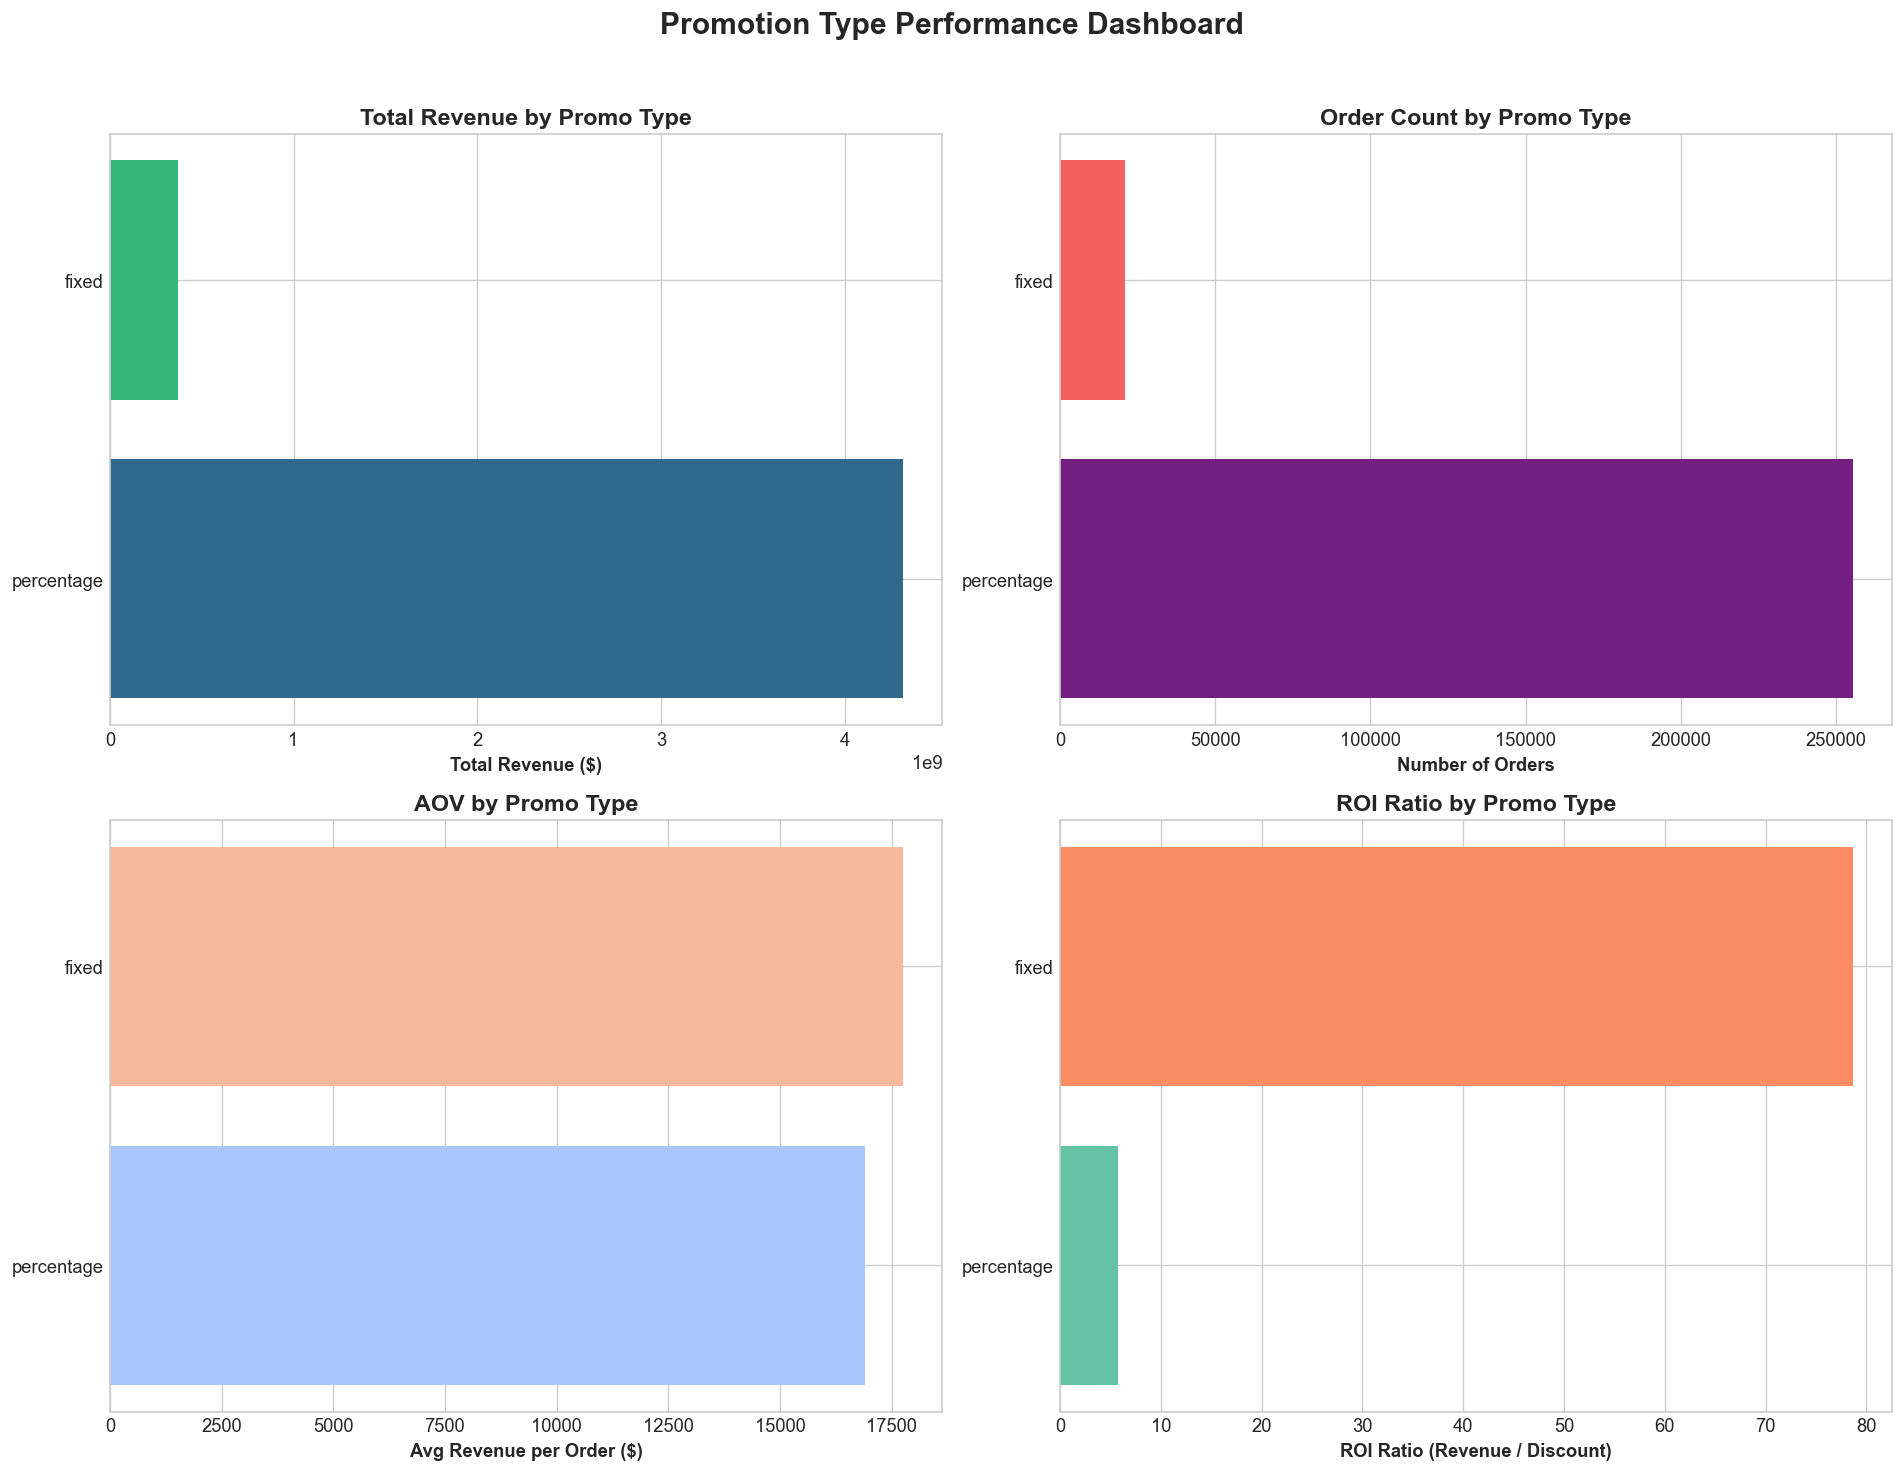

In [53]:
# ============================================================
# CELL 16: 3.3b — Promo Type Charts
# ============================================================
perf_pd = promo_perf.to_pandas()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# (1) Total Revenue by Promo Type
axes[0, 0].barh(perf_pd["promo_type"], perf_pd["total_revenue"], color=sns.color_palette("viridis", len(perf_pd)))
axes[0, 0].set_xlabel("Total Revenue ($)", fontweight="bold")
axes[0, 0].set_title("Total Revenue by Promo Type", fontweight="bold")

# (2) Number of Orders by Promo Type
axes[0, 1].barh(perf_pd["promo_type"], perf_pd["n_orders"], color=sns.color_palette("magma", len(perf_pd)))
axes[0, 1].set_xlabel("Number of Orders", fontweight="bold")
axes[0, 1].set_title("Order Count by Promo Type", fontweight="bold")

# (3) AOV by Promo Type
axes[1, 0].barh(perf_pd["promo_type"], perf_pd["avg_revenue"], color=sns.color_palette("coolwarm", len(perf_pd)))
axes[1, 0].set_xlabel("Avg Revenue per Order ($)", fontweight="bold")
axes[1, 0].set_title("AOV by Promo Type", fontweight="bold")

# (4) ROI Ratio
axes[1, 1].barh(perf_pd["promo_type"], perf_pd["roi_ratio"], color=sns.color_palette("Set2", len(perf_pd)))
axes[1, 1].set_xlabel("ROI Ratio (Revenue / Discount)", fontweight="bold")
axes[1, 1].set_title("ROI Ratio by Promo Type", fontweight="bold")

plt.suptitle("Promotion Type Performance Dashboard", fontsize=18, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "day3_promo_type_performance.png"), bbox_inches="tight")
plt.show()


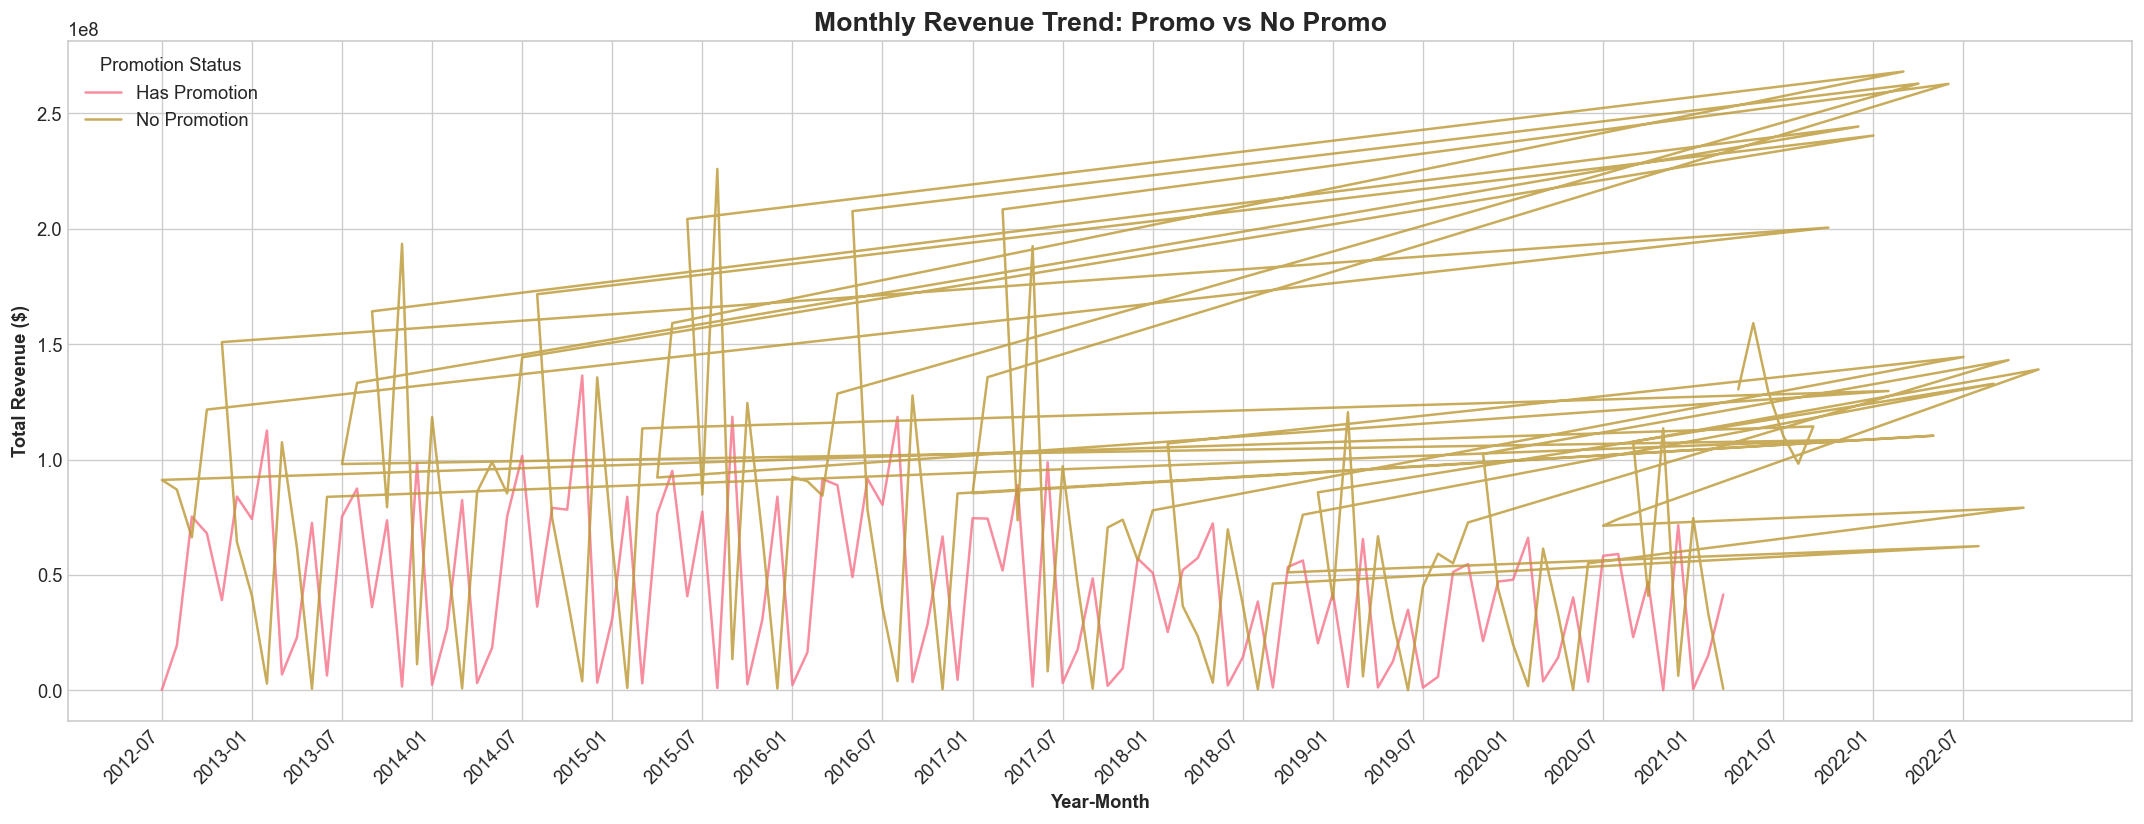

In [54]:
# ============================================================
# CELL 17: 3.4 — Promotion Effectiveness Over Time (Bonus)
# ============================================================
# Thêm Year/Month từ order_date
if "order_date" in master.columns:
    master = master.with_columns([
        pl.col("order_date").dt.year().alias("year"),
        pl.col("order_date").dt.month().alias("month"),
        pl.col("order_date").dt.quarter().alias("quarter"),
    ])

    # Revenue theo thời gian: Promo vs No Promo
    monthly_rev = master.group_by(["year", "month", "has_promo_label"]).agg(
        pl.col("line_revenue").sum().alias("total_revenue"),
        pl.count().alias("n_orders"),
    ).sort(["year", "month"])

    # Pivot cho dễ vẽ
    monthly_pd = monthly_rev.to_pandas()
    monthly_pd["year_month"] = monthly_pd["year"].astype(str) + "-" + monthly_pd["month"].astype(str).str.zfill(2)

    fig, ax = plt.subplots(figsize=(18, 7))
    for label, grp in monthly_pd.groupby("has_promo_label"):
        ax.plot(grp["year_month"], grp["total_revenue"], label=label, linewidth=1.5, alpha=0.8)

    ax.set_title("Monthly Revenue Trend: Promo vs No Promo", fontsize=16, fontweight="bold")
    ax.set_xlabel("Year-Month", fontweight="bold")
    ax.set_ylabel("Total Revenue ($)", fontweight="bold")
    ax.legend(title="Promotion Status", fontsize=11)
    # Chỉ hiện 1 tick mỗi 6 tháng để không bị rối
    tick_labels = monthly_pd["year_month"].unique()
    ax.set_xticks(range(0, len(tick_labels), 6))
    ax.set_xticklabels(tick_labels[::6], rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "day3_monthly_revenue_trend.png"), bbox_inches="tight")
    plt.show()


=== Promo Channel Performance ===
shape: (5, 4)
┌───────────────┬──────────┬───────────────┬──────────────┐
│ promo_channel ┆ n_orders ┆ total_revenue ┆ avg_revenue  │
│ ---           ┆ ---      ┆ ---           ┆ ---          │
│ str           ┆ u32      ┆ f64           ┆ f64          │
╞═══════════════╪══════════╪═══════════════╪══════════════╡
│ all_channels  ┆ 127687   ┆ 1.9861e9      ┆ 15554.671994 │
│ online        ┆ 66171    ┆ 1.2581e9      ┆ 19013.361559 │
│ email         ┆ 41576    ┆ 8.0362e8      ┆ 19329.04955  │
│ social_media  ┆ 31977    ┆ 5.6512e8      ┆ 17672.663977 │
│ in_store      ┆ 8905     ┆ 7.2824e7      ┆ 8177.913742  │
└───────────────┴──────────┴───────────────┴──────────────┘


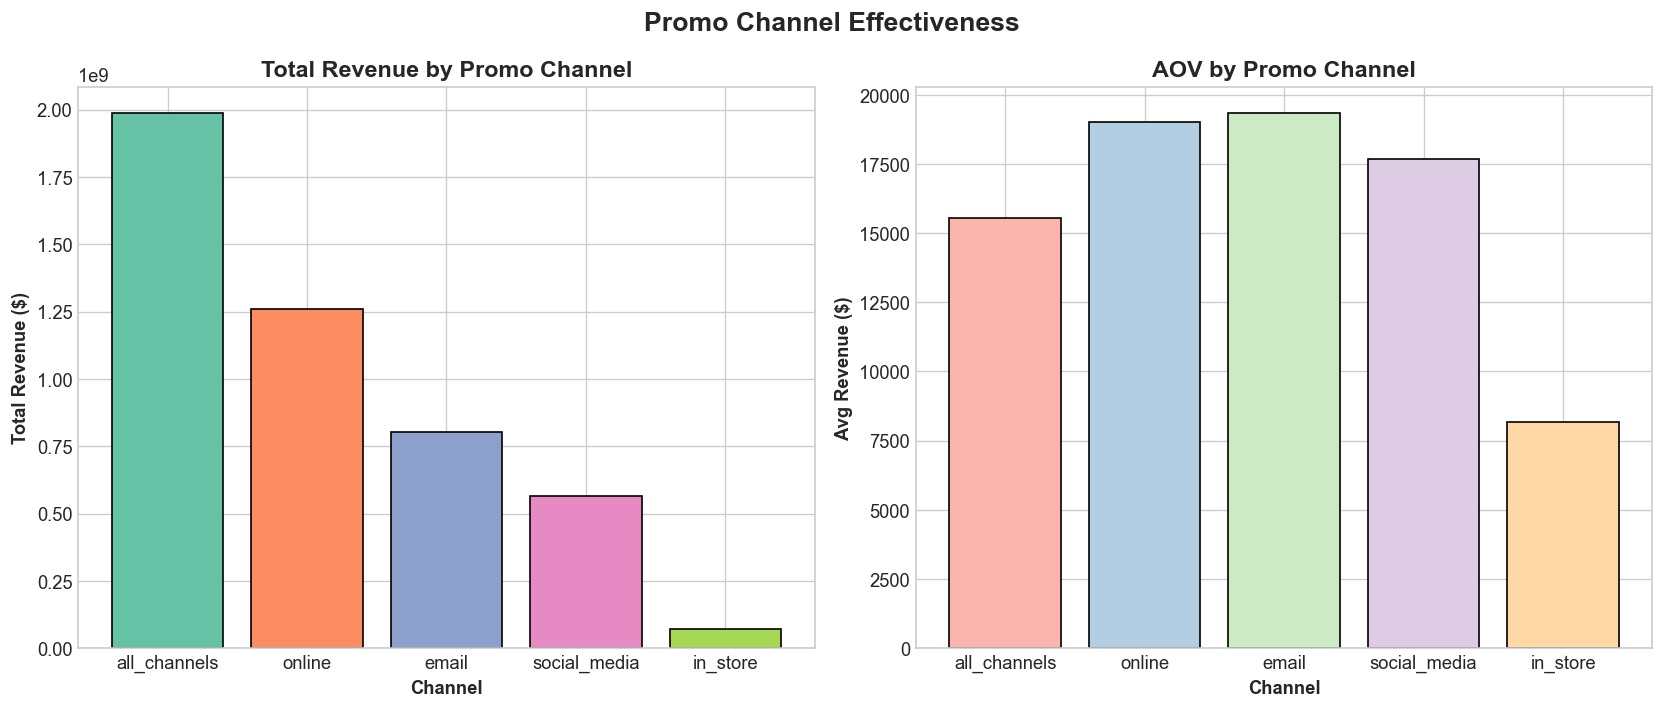

In [55]:
# ============================================================
# CELL 18: 3.5 — Promo Channel Analysis (Bonus)
# ============================================================
if "promo_channel" in master.columns:
    channel_perf = promo_only.group_by("promo_channel").agg(
        pl.count().alias("n_orders"),
        pl.col("line_revenue").sum().alias("total_revenue"),
        pl.col("line_revenue").mean().alias("avg_revenue"),
    ).sort("total_revenue", descending=True)
    print("=== Promo Channel Performance ===")
    print(channel_perf)

    ch_pd = channel_perf.to_pandas()
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].bar(ch_pd["promo_channel"], ch_pd["total_revenue"],
                color=sns.color_palette("Set2", len(ch_pd)), edgecolor="black")
    axes[0].set_title("Total Revenue by Promo Channel", fontweight="bold")
    axes[0].set_ylabel("Total Revenue ($)", fontweight="bold")
    axes[0].set_xlabel("Channel", fontweight="bold")

    axes[1].bar(ch_pd["promo_channel"], ch_pd["avg_revenue"],
                color=sns.color_palette("Pastel1", len(ch_pd)), edgecolor="black")
    axes[1].set_title("AOV by Promo Channel", fontweight="bold")
    axes[1].set_ylabel("Avg Revenue ($)", fontweight="bold")
    axes[1].set_xlabel("Channel", fontweight="bold")

    plt.suptitle("Promo Channel Effectiveness", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "day3_promo_channel.png"), bbox_inches="tight")
    plt.show()

In [60]:
# ============================================================
# CELL 19: 3.6 — Stackable Promotion Impact (Bonus)
# ============================================================
if "stackable_flag" in master.columns and "promo_id_2" in master.columns:
    master = master.with_columns(
        pl.when(pl.col("promo_id_2").is_not_null() & (pl.col("promo_id_2") != ""))
        .then(pl.lit("Stacked (2 Promos)"))
        .otherwise(
            pl.when(pl.col("promo_type") != "No_Promo")
            .then(pl.lit("Single Promo"))
            .otherwise(pl.lit("No Promo"))
        )
        .alias("promo_stack_label")
    )

    stack_perf = master.group_by("promo_stack_label").agg(
        pl.count().alias("n_orders"),
        pl.col("line_revenue").sum().alias("total_revenue"),
        pl.col("line_revenue").mean().alias("avg_revenue"),
        pl.col("discount_amount").mean().alias("avg_discount"),
    )
    print("=== Stacked Promo Impact ===")
    print(stack_perf)

    st_pd = stack_perf.to_pandas()
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(st_pd["promo_stack_label"], st_pd["avg_revenue"],
                  color=["#95a5a6", "#3498db", "#e67e22"], edgecolor="black")
    for bar, val in zip(bars, st_pd["avg_revenue"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                f"${val:,.0f}", ha="center", fontweight="bold")
    ax.set_title("AOV: No Promo vs Single vs Stacked Promotions", fontweight="bold")
    ax.set_ylabel("Average Order Value ($)", fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "day3_stacked_promo.png"), bbox_inches="tight")
    plt.show()


# 🎯 TỔNG KẾT INSIGHTS (SESSION 3: PROMOTIONS ANALYSIS)

Sau khi phân tích cắt lớp dữ liệu khuyến mãi theo nhiều chiều (Loại hình, Thời gian, Kênh phân phối), chúng ta rút ra 3 kết luận chiến lược mang tính quyết định cho hoạt động kinh doanh:

### 1. Sự thật mất lòng về "Khuyến mãi theo %" (Percentage vs Fixed)
*   **Thực trạng:** Khuyến mãi giảm theo phần trăm (`percentage`) đang chiếm thế độc tôn (255k đơn hàng, tạo ra 4.3 tỷ $ doanh thu). Tuy nhiên, ROI của nó cực kỳ tệ (chỉ đạt ~5.8). Nghĩa là cứ giảm 1$ thì thu về chưa tới 6$.
*   **Điểm sáng:** Khuyến mãi giảm giá cố định (`fixed`) dù có số lượng ít hơn hẳn (chỉ 20k đơn) nhưng lại mang về AOV nhỉnh hơn ($17.7k vs $16.9k) và đặc biệt là **ROI khổng lồ lên tới 78.6**.
* **➤ Actionable Takeaway:** Doanh nghiệp đang bị "chảy máu biên lợi nhuận" (margin erosion) vì quá lạm dụng mã giảm %. Cần lập tức dịch chuyển ngân sách sang các mã giảm giá Fixed (Ví dụ: Giảm thẳng 500k cho đơn từ 5 triệu) để bảo vệ lợi nhuận mà vẫn duy trì được AOV tốt.

### 2. Hành vi mua sắm qua Kênh phân phối (Promo Channels)
*   **Chất lượng khách hàng:** Kênh **`email`** và **`online`** đang là mỏ vàng thực sự. Dù lượng đơn hàng không bằng `all_channels`, nhưng AOV của hai kênh này cao nhất (lần lượt đạt $19k và $19.3k). Điều này cho thấy tập khách hàng nhận email là tập khách hàng trung thành, sẵn sàng chi trả cao.
*   **Vùng trũng:** Kênh `in_store` (tại cửa hàng) có hiệu quả rất thấp cả về tổng doanh thu lẫn AOV ($8.1k). Khuyến mãi offline đang không kích thích được khách mua thêm.
*   **➤ Actionable Takeaway:** Cắt giảm ngân sách khuyến mãi rải rác ở cửa hàng vật lý, dồn lực thiết kế các chiến dịch E-mail Marketing cá nhân hóa (Personalized Email) dành riêng cho tập khách hàng VIP để tối đa hóa doanh thu.

### 3. Tác động của Khuyến mãi theo Thời gian (Trend over Time)
*   Nhìn vào biểu đồ chuỗi thời gian (2012 - 2022), doanh thu từ nhóm `No Promotion` (đường màu vàng) luôn luôn đóng vai trò là cột sống (Backbone) và duy trì sự thống trị so với `Has Promotion`.
*   Điều này một lần nữa khẳng định: Sản phẩm của doanh nghiệp có tính cạnh tranh tự nhiên rất cao. Các đỉnh (Spikes) của khuyến mãi có tạo ra cú hích, nhưng không làm lu mờ được doanh thu tự nhiên.
*   Dành cho mô hình Forecasting (Mục tiêu ngày tiếp theo):** Không cần thiết phải bơm quá nhiều "trọng số" (weight) cho biến khuyến mãi. Mô hình dự báo (như XGBoost/Prophet) nên tập trung vào việc học tính mùa vụ (Seasonality) của dòng `No Promotion`, còn biến `has_promotion` chỉ nên dùng như một tín hiệu nhiễu (anomaly signal) để điều chỉnh các đỉnh doanh thu.


# ============================================================
# SECTION 4: FEATURE ENGINEERING FOR FORECASTING
# ============================================================


In [57]:
# ============================================================
# CELL 20: 4.1 — Create Promotion Features
# ============================================================
master = master.with_columns([
    # Binary: có khuyến mãi hay không
    pl.when(pl.col("promo_type") != "No_Promo")
    .then(pl.lit(1))
    .otherwise(pl.lit(0))
    .alias("has_promotion"),

    # Discount percentage = discount_amount / (quantity * unit_price) * 100
    pl.when(pl.col("quantity") * pl.col("unit_price") > 0)
    .then(pl.col("discount_amount") / (pl.col("quantity") * pl.col("unit_price")) * 100)
    .otherwise(pl.lit(0.0))
    .alias("discount_pct"),
])

print("=== Feature Preview ===")
feat_cols = ["order_id", "promo_type", "has_promotion", "discount_pct",
             "discount_amount", "line_revenue"]
print(master.select([c for c in feat_cols if c in master.columns]).head(10))
print(f"\nhas_promotion distribution:\n{master['has_promotion'].value_counts()}")

=== Feature Preview ===
shape: (10, 6)
┌──────────┬────────────┬───────────────┬──────────────┬─────────────────┬──────────────┐
│ order_id ┆ promo_type ┆ has_promotion ┆ discount_pct ┆ discount_amount ┆ line_revenue │
│ ---      ┆ ---        ┆ ---           ┆ ---          ┆ ---             ┆ ---          │
│ str      ┆ str        ┆ i32           ┆ f64          ┆ f64             ┆ f64          │
╞══════════╪════════════╪═══════════════╪══════════════╪═════════════════╪══════════════╡
│ 1        ┆ No_Promo   ┆ 0             ┆ 0.0          ┆ 0.0             ┆ 7967.54      │
│ 2        ┆ No_Promo   ┆ 0             ┆ 0.0          ┆ 0.0             ┆ 71163.75     │
│ 3        ┆ No_Promo   ┆ 0             ┆ 0.0          ┆ 0.0             ┆ 33660.99     │
│ 4        ┆ No_Promo   ┆ 0             ┆ 0.0          ┆ 0.0             ┆ 53196.25     │
│ 6        ┆ No_Promo   ┆ 0             ┆ 0.0          ┆ 0.0             ┆ 1597.84      │
│ 7        ┆ No_Promo   ┆ 0             ┆ 0.0          ┆ 0.0 

In [58]:
# ============================================================
# CELL 21: 4.2 — Export Processed Data
# ============================================================
DATA_DIR = os.path.abspath(os.path.join("..", "Data"))

export_cols = [
    "order_id", "product_id", "customer_id", "order_date",
    "quantity", "unit_price", "discount_amount", "line_revenue",
    "promo_id", "promo_type", "promo_channel",
    "has_promotion", "discount_pct",
    "order_status", "payment_method", "device_type", "order_source",
    "flag_negative_revenue",
]
# Chỉ giữ các cột tồn tại
export_cols = [c for c in export_cols if c in master.columns]

master_export = master.select(export_cols)
export_path = os.path.join(DATA_DIR, "processed_promo_features.parquet")
master_export.write_parquet(export_path)
print(f"✅ Exported {master_export.shape} to {export_path}")
print(f"   File size: {os.path.getsize(export_path) / 1e6:.2f} MB")

✅ Exported (714669, 18) to /Users/khanhnq35/Documents/Datathon_Outliers/Data/processed_promo_features.parquet
   File size: 14.51 MB


In [59]:
# ============================================================
# CELL 22: Summary Statistics & Final Narrative
# ============================================================
print("=" * 60)
print("📝 SUMMARY — Day 3 Promotions EDA")
print("=" * 60)
print(f"Total order lines analyzed: {master.height:,}")

has_promo = master.filter(pl.col("has_promotion") == 1).height
no_promo = master.filter(pl.col("has_promotion") == 0).height
print(f"With Promotion:    {has_promo:,} ({has_promo/master.height*100:.1f}%)")
print(f"Without Promotion: {no_promo:,} ({no_promo/master.height*100:.1f}%)")

rev_promo = master.filter(pl.col("has_promotion") == 1)["line_revenue"].sum()
rev_no = master.filter(pl.col("has_promotion") == 0)["line_revenue"].sum()
print(f"\nRevenue (Promo):    ${rev_promo:,.0f}")
print(f"Revenue (No Promo): ${rev_no:,.0f}")

aov_promo = master.filter(pl.col("has_promotion") == 1)["line_revenue"].mean()
aov_no = master.filter(pl.col("has_promotion") == 0)["line_revenue"].mean()
print(f"\nAOV (Promo):    ${aov_promo:,.2f}")
print(f"AOV (No Promo): ${aov_no:,.2f}")

if "promo_type" in master.columns:
    best = promo_perf.row(0)
    print(f"\nBest performing promo type: {best[0]} (Revenue: ${best[2]:,.0f})")

print("\n" + "=" * 60)
print("📊 Figures saved to:", FIGURES_DIR)
print("📦 Features exported to:", export_path)
print("=" * 60)


📝 SUMMARY — Day 3 Promotions EDA
Total order lines analyzed: 714,669
With Promotion:    276,316 (38.7%)
Without Promotion: 438,353 (61.3%)

Revenue (Promo):    $4,685,830,213
Revenue (No Promo): $10,995,039,053

AOV (Promo):    $16,958.23
AOV (No Promo): $25,082.61

Best performing promo type: percentage (Revenue: $4,314,083,021)

📊 Figures saved to: /Users/khanhnq35/Documents/Datathon_Outliers/figures
📦 Features exported to: /Users/khanhnq35/Documents/Datathon_Outliers/Data/processed_promo_features.parquet
